Load Libraries

In [1]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.applications.resnet50 import decode_predictions
from tensorflow.keras.applications.resnet50 import preprocess_input
import tensorflow as tf
import numpy as np
import argparse
import cv2
import pandas as pd
import pickle
import copy 
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

Program for FGSM attack

In [2]:
def create_adversarial_pattern(model, input_image, input_label):
    y_orinal = tf.keras.utils.to_categorical(input_label, num_classes)
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = tf.transpose(model(input_image, training=False))
        loss = sccLoss(tf.convert_to_tensor(y_orinal), prediction)

    # Get the gradients of the loss w.r.t to the input image.
    gradient = tape.gradient(loss, input_image)
    # Get the sign of the gradients to create the perturbation
    signed_grad = tf.sign(gradient)
    return signed_grad



Load Model and normalisation parameters

In [3]:
model = tf.keras.models.load_model("./data/last-model.h5")
model.summary()
with open('./data/dictionary.pkl', 'rb') as f:
    num_classes = pickle.load(f)
    X_min = pickle.load(f)
    X_max = pickle.load(f)
    ipca=pickle.load(f)

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 650)               195650    
_________________________________________________________________
batch_normalization_1 (Batch (None, 650)               2600      
_________________________________________________________________
activation_1 (Activation)    (None, 650)               0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 650)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 600)               390600    
_________________________________________________________________
batch_normalization_2 (Batch (None, 600)               2400      
_________________________________________________________________
activation_2 (Activation)    (None, 600)               0

Load Data

In [4]:
X_poj = pd.read_csv('./csv_data/POJ_104.csv', sep='\t',header=None)
Y_poj = X_poj.loc[:,0]
X_poj = X_poj.loc[:,1:300]
X_poj.columns = range(X_poj.shape[1])
x_poj = (X_poj - X_min) / (X_max - X_min)
x_poj = np.array(x_poj)
x_poj = ipca.transform(x_poj)
Y_poj = np.array(Y_poj)
Y_poj = Y_poj - 1



X_adce = pd.read_csv('./csv_data/POJ_104_adce.csv', sep='\t',header=None)
Y_adce = X_adce.loc[:,0]
X_adce = X_adce.loc[:,1:300]
X_adce.columns = range(X_adce.shape[1])
x_adce = (X_adce - X_min) / (X_max - X_min)
x_adce = np.array(x_adce)
x_adce = ipca.transform(x_adce)
Y_adce = np.array(Y_adce)
Y_adce = Y_adce - 1

X_mem2reg = pd.read_csv('./csv_data/POJ_104_mem2reg.csv', sep='\t',header=None)
Y_mem2reg = X_mem2reg.loc[:,0]
X_mem2reg = X_mem2reg.loc[:,1:300]
X_mem2reg.columns = range(X_mem2reg.shape[1])
x_mem2reg = (X_mem2reg - X_min) / (X_max - X_min)
x_mem2reg = np.array(x_mem2reg)
x_mem2reg = ipca.transform(x_mem2reg)
Y_mem2reg = np.array(Y_mem2reg)
Y_mem2reg = Y_mem2reg - 1

X_loop_rotate = pd.read_csv('./csv_data/POJ_104_loop_rotate.csv', sep='\t',header=None)
Y_loop_rotate = X_loop_rotate.loc[:,0]
X_loop_rotate = X_loop_rotate.loc[:,1:300]
X_loop_rotate.columns = range(X_loop_rotate.shape[1])
x_loop_rotate = (X_loop_rotate - X_min) / (X_max - X_min)
x_loop_rotate = np.array(x_loop_rotate)
x_loop_rotate = ipca.transform(x_loop_rotate)
Y_loop_rotate = np.array(Y_loop_rotate)
Y_loop_rotate = Y_loop_rotate - 1

X_loop_simplify = pd.read_csv('./csv_data/POJ_104_loop_simplify.csv', sep='\t',header=None)
Y_loop_simplify = X_loop_simplify.loc[:,0]
X_loop_simplify = X_loop_simplify.loc[:,1:300]
X_loop_simplify.columns = range(X_loop_simplify.shape[1])
x_loop_simplify = (X_loop_simplify - X_min) / (X_max - X_min)
x_loop_simplify = np.array(x_loop_simplify)
x_loop_simplify = ipca.transform(x_loop_simplify)
Y_loop_simplify = np.array(Y_loop_simplify)
Y_loop_simplify = Y_loop_simplify - 1

X_loop_unroll = pd.read_csv('./csv_data/POJ_104_loop_unroll.csv', sep='\t',header=None)
Y_loop_unroll = X_loop_unroll.loc[:,0]
X_loop_unroll = X_loop_unroll.loc[:,1:300]
X_loop_unroll.columns = range(X_loop_unroll.shape[1])
x_loop_unroll = (X_loop_unroll - X_min) / (X_max - X_min)
x_loop_unroll = np.array(x_loop_unroll)
x_loop_unroll = ipca.transform(x_loop_unroll)
Y_loop_unroll = np.array(Y_loop_unroll)
Y_loop_unroll = Y_loop_unroll - 1

X_loop_vectorize = pd.read_csv('./csv_data/POJ_104_loop_vectorize.csv', sep='\t',header=None)
Y_loop_vectorize = X_loop_vectorize.loc[:,0]
X_loop_vectorize = X_loop_vectorize.loc[:,1:300]
X_loop_vectorize.columns = range(X_loop_vectorize.shape[1])
x_loop_vectorize = (X_loop_vectorize - X_min) / (X_max - X_min)
x_loop_vectorize = np.array(x_loop_vectorize)
x_loop_vectorize = ipca.transform(x_loop_vectorize)
Y_loop_vectorize = np.array(Y_loop_vectorize)
Y_loop_vectorize = Y_loop_vectorize - 1

X_memoryssa = pd.read_csv('./csv_data/POJ_104_memoryssa.csv', sep='\t',header=None)
Y_memoryssa = X_memoryssa.loc[:,0]
X_memoryssa = X_memoryssa.loc[:,1:300]
X_memoryssa.columns = range(X_memoryssa.shape[1])
x_memoryssa = (X_memoryssa - X_min) / (X_max - X_min)
x_memoryssa = np.array(x_memoryssa)
x_memoryssa = ipca.transform(x_memoryssa)
Y_memoryssa = np.array(Y_memoryssa)
Y_memoryssa = Y_memoryssa - 1

X_simplifycfg = pd.read_csv('./csv_data/POJ_104_simplifycfg.csv', sep='\t',header=None)
Y_simplifycfg = X_simplifycfg.loc[:,0]
X_simplifycfg = X_simplifycfg.loc[:,1:300]
X_simplifycfg.columns = range(X_simplifycfg.shape[1])
x_simplifycfg = (X_simplifycfg - X_min) / (X_max - X_min)
x_simplifycfg = np.array(x_simplifycfg)
x_simplifycfg = ipca.transform(x_simplifycfg)
Y_simplifycfg = np.array(Y_simplifycfg)
Y_simplifycfg = Y_simplifycfg - 1

Find the correctly classified input index and shuffle

In [5]:
pred_poj =  model.predict_classes(x_poj, verbose=0)
poj_correct=[]
for i in range(len(pred_poj)):
    if pred_poj[i]==Y_poj[i]:
        poj_correct.append(i)

len(poj_correct)

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


38820

In [6]:
# Shuffle the input
shuffled_index=copy.deepcopy(poj_correct[:30000])

np.random.shuffle(shuffled_index)

In [7]:
len(shuffled_index)

30000

In [8]:
subsetsize=2000

Perform untargeted attack

In [9]:
EPS = 2 / 255.0
LR = 5e-5

optimizer = Adam(lr=LR,beta_1=0.9, beta_2=0.999, epsilon=None,decay=0.0, amsgrad=False)
sccLoss = CategoricalCrossentropy()

In [10]:
x_adv_1 = []
y_adv_1 = []
for i in range(subsetsize):
    index=shuffled_index[i]
    baseImage = tf.constant(x_poj[index:index+1], dtype=tf.float32)
    perturbations = create_adversarial_pattern(model, baseImage, Y_poj[index])
    epsilons = [0, 0.01, 0.1, 0.15]
    eps = .01
    adv_x = baseImage + eps*perturbations
    predicted_y = model.predict_classes(adv_x, batch_size=32, verbose=2)
    print(i, predicted_y[0], Y_poj[index])
    x_adv_1.append(adv_x)
    y_adv_1.append(predicted_y)


1/1 - 0s
0 84 0
1/1 - 0s
1 99 37
1/1 - 0s
2 18 3
1/1 - 0s
3 18 78
1/1 - 0s
4 86 64
1/1 - 0s
5 91 4
1/1 - 0s
6 43 10
1/1 - 0s
7 3 21
1/1 - 0s
8 81 67
1/1 - 0s
9 103 59
1/1 - 0s
10 19 3
1/1 - 0s
11 3 33
1/1 - 0s
12 51 73
1/1 - 0s
13 80 64
1/1 - 0s
14 19 74
1/1 - 0s
15 11 7
1/1 - 0s
16 18 42
1/1 - 0s
17 18 44
1/1 - 0s
18 103 73
1/1 - 0s
19 18 36
1/1 - 0s
20 61 66
1/1 - 0s
21 85 76
1/1 - 0s
22 31 71
1/1 - 0s
23 49 8
1/1 - 0s
24 70 49
1/1 - 0s
25 19 54
1/1 - 0s
26 45 64
1/1 - 0s
27 18 63
1/1 - 0s
28 61 62
1/1 - 0s
29 70 45
1/1 - 0s
30 19 0
1/1 - 0s
31 91 79
1/1 - 0s
32 23 0
1/1 - 0s
33 23 35
1/1 - 0s
34 16 79
1/1 - 0s
35 23 79
1/1 - 0s
36 19 1
1/1 - 0s
37 51 16
1/1 - 0s
38 45 63
1/1 - 0s
39 100 6
1/1 - 0s
40 35 45
1/1 - 0s
41 21 67
1/1 - 0s
42 45 23
1/1 - 0s
43 84 59
1/1 - 0s
44 18 28
1/1 - 0s
45 51 47
1/1 - 0s
46 19 55
1/1 - 0s
47 57 8
1/1 - 0s
48 51 11
1/1 - 0s
49 99 15
1/1 - 0s
50 51 76
1/1 - 0s
51 47 73
1/1 - 0s
52 19 57
1/1 - 0s
53 99 53
1/1 - 0s
54 5 70
1/1 - 0s
55 23 38
1/1 - 0s
56 5

441 74 73
1/1 - 0s
442 3 75
1/1 - 0s
443 19 72
1/1 - 0s
444 45 59
1/1 - 0s
445 79 49
1/1 - 0s
446 22 52
1/1 - 0s
447 23 79
1/1 - 0s
448 99 53
1/1 - 0s
449 19 74
1/1 - 0s
450 103 59
1/1 - 0s
451 18 3
1/1 - 0s
452 23 28
1/1 - 0s
453 22 56
1/1 - 0s
454 79 24
1/1 - 0s
455 21 31
1/1 - 0s
456 79 29
1/1 - 0s
457 22 5
1/1 - 0s
458 70 79
1/1 - 0s
459 19 41
1/1 - 0s
460 51 44
1/1 - 0s
461 22 5
1/1 - 0s
462 83 19
1/1 - 0s
463 19 48
1/1 - 0s
464 18 78
1/1 - 0s
465 13 45
1/1 - 0s
466 24 50
1/1 - 0s
467 74 78
1/1 - 0s
468 35 53
1/1 - 0s
469 6 24
1/1 - 0s
470 22 5
1/1 - 0s
471 84 8
1/1 - 0s
472 85 73
1/1 - 0s
473 60 56
1/1 - 0s
474 41 9
1/1 - 0s
475 51 69
1/1 - 0s
476 19 11
1/1 - 0s
477 18 46
1/1 - 0s
478 18 14
1/1 - 0s
479 45 3
1/1 - 0s
480 49 65
1/1 - 0s
481 103 2
1/1 - 0s
482 3 66
1/1 - 0s
483 31 42
1/1 - 0s
484 79 19
1/1 - 0s
485 21 67
1/1 - 0s
486 5 57
1/1 - 0s
487 103 40
1/1 - 0s
488 22 62
1/1 - 0s
489 79 43
1/1 - 0s
490 61 66
1/1 - 0s
491 86 59
1/1 - 0s
492 11 1
1/1 - 0s
493 19 18
1/1 - 0s
494

1/1 - 0s
877 79 37
1/1 - 0s
878 45 39
1/1 - 0s
879 31 29
1/1 - 0s
880 18 48
1/1 - 0s
881 74 69
1/1 - 0s
882 99 75
1/1 - 0s
883 99 33
1/1 - 0s
884 41 12
1/1 - 0s
885 47 58
1/1 - 0s
886 51 58
1/1 - 0s
887 19 15
1/1 - 0s
888 84 22
1/1 - 0s
889 61 32
1/1 - 0s
890 31 71
1/1 - 0s
891 21 67
1/1 - 0s
892 72 54
1/1 - 0s
893 18 71
1/1 - 0s
894 51 12
1/1 - 0s
895 83 67
1/1 - 0s
896 11 74
1/1 - 0s
897 23 63
1/1 - 0s
898 22 44
1/1 - 0s
899 22 73
1/1 - 0s
900 51 72
1/1 - 0s
901 96 40
1/1 - 0s
902 47 50
1/1 - 0s
903 86 21
1/1 - 0s
904 51 69
1/1 - 0s
905 19 20
1/1 - 0s
906 19 42
1/1 - 0s
907 3 21
1/1 - 0s
908 23 52
1/1 - 0s
909 86 64
1/1 - 0s
910 51 72
1/1 - 0s
911 64 47
1/1 - 0s
912 64 60
1/1 - 0s
913 103 19
1/1 - 0s
914 57 62
1/1 - 0s
915 21 67
1/1 - 0s
916 96 70
1/1 - 0s
917 19 53
1/1 - 0s
918 3 21
1/1 - 0s
919 48 62
1/1 - 0s
920 80 2
1/1 - 0s
921 5 58
1/1 - 0s
922 21 30
1/1 - 0s
923 13 58
1/1 - 0s
924 96 43
1/1 - 0s
925 6 74
1/1 - 0s
926 79 47
1/1 - 0s
927 21 24
1/1 - 0s
928 84 46
1/1 - 0s
929 83 

1297 51 48
1/1 - 0s
1298 74 42
1/1 - 0s
1299 79 72
1/1 - 0s
1300 48 62
1/1 - 0s
1301 3 63
1/1 - 0s
1302 19 15
1/1 - 0s
1303 23 52
1/1 - 0s
1304 36 14
1/1 - 0s
1305 22 13
1/1 - 0s
1306 18 3
1/1 - 0s
1307 61 1
1/1 - 0s
1308 13 4
1/1 - 0s
1309 24 40
1/1 - 0s
1310 3 33
1/1 - 0s
1311 86 8
1/1 - 0s
1312 3 21
1/1 - 0s
1313 61 70
1/1 - 0s
1314 41 34
1/1 - 0s
1315 2 33
1/1 - 0s
1316 45 3
1/1 - 0s
1317 86 41
1/1 - 0s
1318 57 63
1/1 - 0s
1319 41 34
1/1 - 0s
1320 57 65
1/1 - 0s
1321 47 40
1/1 - 0s
1322 19 0
1/1 - 0s
1323 62 11
1/1 - 0s
1324 26 0
1/1 - 0s
1325 62 62
1/1 - 0s
1326 87 47
1/1 - 0s
1327 3 19
1/1 - 0s
1328 86 35
1/1 - 0s
1329 22 36
1/1 - 0s
1330 48 80
1/1 - 0s
1331 100 30
1/1 - 0s
1332 23 0
1/1 - 0s
1333 91 43
1/1 - 0s
1334 22 5
1/1 - 0s
1335 11 7
1/1 - 0s
1336 45 32
1/1 - 0s
1337 50 32
1/1 - 0s
1338 19 29
1/1 - 0s
1339 23 24
1/1 - 0s
1340 3 46
1/1 - 0s
1341 96 19
1/1 - 0s
1342 47 50
1/1 - 0s
1343 23 9
1/1 - 0s
1344 70 65
1/1 - 0s
1345 18 49
1/1 - 0s
1346 48 33
1/1 - 0s
1347 21 31
1/1 -

1/1 - 0s
1712 37 75
1/1 - 0s
1713 3 63
1/1 - 0s
1714 22 5
1/1 - 0s
1715 45 37
1/1 - 0s
1716 64 1
1/1 - 0s
1717 41 55
1/1 - 0s
1718 18 48
1/1 - 0s
1719 96 17
1/1 - 0s
1720 18 77
1/1 - 0s
1721 86 29
1/1 - 0s
1722 41 34
1/1 - 0s
1723 41 24
1/1 - 0s
1724 79 37
1/1 - 0s
1725 83 58
1/1 - 0s
1726 47 6
1/1 - 0s
1727 83 67
1/1 - 0s
1728 78 20
1/1 - 0s
1729 57 78
1/1 - 0s
1730 99 51
1/1 - 0s
1731 45 7
1/1 - 0s
1732 32 73
1/1 - 0s
1733 51 48
1/1 - 0s
1734 19 53
1/1 - 0s
1735 23 24
1/1 - 0s
1736 30 10
1/1 - 0s
1737 3 19
1/1 - 0s
1738 64 76
1/1 - 0s
1739 51 34
1/1 - 0s
1740 18 24
1/1 - 0s
1741 84 75
1/1 - 0s
1742 19 32
1/1 - 0s
1743 99 17
1/1 - 0s
1744 51 33
1/1 - 0s
1745 61 51
1/1 - 0s
1746 22 44
1/1 - 0s
1747 81 19
1/1 - 0s
1748 18 11
1/1 - 0s
1749 41 11
1/1 - 0s
1750 100 40
1/1 - 0s
1751 79 69
1/1 - 0s
1752 21 36
1/1 - 0s
1753 64 79
1/1 - 0s
1754 90 16
1/1 - 0s
1755 96 17
1/1 - 0s
1756 19 41
1/1 - 0s
1757 23 62
1/1 - 0s
1758 64 76
1/1 - 0s
1759 79 73
1/1 - 0s
1760 90 57
1/1 - 0s
1761 99 46
1/1 -

In [12]:
initial_adversaries1=[]
for i in range(len(x_adv_1)):
    x=x_adv_1[i].numpy().tolist()
    initial_adversaries1.append(x[0])
initial_adversaries1=np.array(initial_adversaries1)

In [30]:
len(initial_adversaries1)

2000

Check how many out of 2000 have same class label as initial

In [13]:
pred_poj_adv=  model.predict_classes(initial_adversaries1, verbose=0)
# poj_correct=[i for i, j in zip(pred_poj, Y_poj) if i == j]
y_correct_poj=[]
for i in range(2000):
    index=shuffled_index[i]
    if pred_poj_adv[i]==Y_poj[index]:
        y_correct_poj.append(Y_poj[index])

In [14]:
len(y_correct_poj)

9

Calculate accuracy

In [15]:
y_new_categorical = tf.keras.utils.to_categorical(pred_poj_adv, num_classes)
score = model.evaluate(initial_adversaries1, y_new_categorical, verbose=0)
print('Accuracy of model on non targeted attack : {acc:.3f}%'.format(acc=(1-score[1])*100))

Accuracy of model on non targeted attack : 0.000%


Find the nearest transformation for given adversary

In [16]:
def printclass(count,minimum,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==adce_dist):
        print("adce")
        count[0]=count[0]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[1]=count[1]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[2]=count[2]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[3]=count[3]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[4]=count[4]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[5]=count[5]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[6]=count[6]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[7]=count[7]+1;

In [17]:
subsetsize

2000

In [19]:
count=[0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(index)+"  ")
    printclass(count,minimum,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

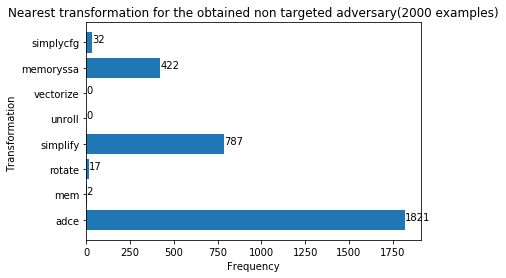

In [20]:
x = ["adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained non targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))


In [21]:
count

[1821, 2, 17, 787, 0, 0, 422, 32]

Find the nearest transformation for given adversary (consider input also)

In [22]:
def printclass1(count,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist):
    if(minimum==poj_dist):
        print("poj")
        count[0]=count[0]+1;
    if(minimum==adce_dist):
        print("adce")
        count[1]=count[1]+1;
    if(minimum==mem2reg_dist):
        print("mem2reg")
        count[2]=count[2]+1;
    if(minimum==loop_rotate_dist):
        print("loop_rotate")
        count[3]=count[3]+1;
    if(minimum==loop_simplify_dist):
        print("loop_simplify")
        count[4]=count[4]+1;
    if(minimum==loop_unroll_dist):
        print("loop_unroll")
        count[5]=count[5]+1;
    if(minimum==loop_vectorize_dist):
        print("loop_vectorize")
        count[6]=count[6]+1;
    if(minimum==memoryssa_dist):
        print("memoryssa")
        count[7]=count[7]+1;
    if(minimum==simplifycfg_dist):
        print("simplifycfg")
        count[8]=count[8]+1;

In [25]:
count3=[0,0,0,0,0,0,0,0,0]
for index in range(subsetsize):
    i=shuffled_index[index]
    poj_dist=np.linalg.norm(x_poj[i] - initial_adversaries1[index])
    adce_dist=np.linalg.norm(x_adce[i] - initial_adversaries1[index])
    mem2reg_dist=np.linalg.norm(x_mem2reg[i] - initial_adversaries1[index])
    loop_rotate_dist=np.linalg.norm(x_loop_rotate[i] - initial_adversaries1[index])
    loop_simplify_dist=np.linalg.norm(x_loop_simplify[i] - initial_adversaries1[index])
    loop_unroll_dist=np.linalg.norm(x_loop_unroll[i] - initial_adversaries1[index])
    loop_vectorize_dist=np.linalg.norm(x_loop_vectorize[i] - initial_adversaries1[index])
    memoryssa_dist=np.linalg.norm(x_memoryssa[i] - initial_adversaries1[index])
    simplifycfg_dist=np.linalg.norm(x_simplifycfg[i] - initial_adversaries1[index])
    minimum=min(poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)
    print("For "+str(i)+"  ")
    printclass1(count3,minimum,poj_dist,adce_dist,mem2reg_dist,loop_rotate_dist,loop_simplify_dist,loop_unroll_dist,loop_vectorize_dist,memoryssa_dist,simplifycfg_dist)

For 102  
simplifycfg
For 14221  
poj
adce
For 1338  
poj
adce
loop_simplify
memoryssa
For 31020  
poj
adce
For 25183  
poj
loop_simplify
For 2037  
poj
adce
loop_simplify
memoryssa
For 4202  
poj
adce
loop_simplify
memoryssa
For 8567  
poj
adce
For 26257  
poj
adce
For 23284  
poj
adce
For 1309  
poj
loop_simplify
memoryssa
For 12356  
poj
adce
For 29037  
poj
adce
For 24981  
poj
adce
loop_simplify
For 29500  
poj
For 3138  
adce
For 16391  
poj
adce
For 16987  
poj
adce
For 28988  
poj
adce
For 13801  
poj
adce
For 25875  
poj
adce
loop_simplify
For 30276  
poj
adce
For 28277  
poj
adce
For 3595  
poj
adce
loop_simplify
memoryssa
For 18958  
poj
adce
loop_simplify
For 21451  
poj
adce
loop_simplify
For 25049  
poj
adce
loop_simplify
For 24811  
poj
adce
loop_simplify
For 24305  
poj
adce
loop_simplify
For 17501  
poj
adce
For 184  
loop_rotate
For 31724  
adce
For 228  
poj
loop_simplify
memoryssa
For 13591  
poj
adce
For 31622  
poj
adce
For 31719  
poj
adce
For 795  
simplifycfg
F

adce
loop_simplify
For 9510  
poj
For 27792  
poj
adce
For 27734  
poj
adce
For 8631  
poj
adce
For 27247  
poj
adce
For 23310  
poj
adce
loop_simplify
For 14682  
poj
For 31411  
poj
adce
For 22845  
poj
adce
loop_simplify
For 13056  
poj
adce
For 17557  
poj
adce
For 30088  
poj
adce
For 6705  
poj
adce
loop_simplify
memoryssa
For 28336  
poj
adce
For 27342  
adce
For 11283  
poj
adce
For 25417  
poj
adce
loop_simplify
For 14824  
poj
adce
For 26097  
poj
adce
loop_simplify
For 11150  
poj
adce
For 18731  
poj
adce
For 30223  
poj
adce
For 6102  
poj
adce
loop_simplify
memoryssa
For 17810  
poj
adce
For 6972  
poj
adce
loop_simplify
memoryssa
For 13845  
poj
adce
For 3203  
poj
loop_simplify
memoryssa
For 7266  
poj
adce
loop_simplify
memoryssa
For 4090  
poj
adce
loop_simplify
memoryssa
For 8078  
poj
adce
For 25426  
poj
loop_simplify
For 28141  
poj
adce
For 10570  
poj
adce
For 29516  
poj
adce
For 20482  
loop_simplify
For 1698  
poj
adce
loop_simplify
memoryssa
For 97  
poj
adc

For 2937  
poj
adce
loop_simplify
memoryssa
For 14246  
poj
adce
For 13627  
poj
adce
For 6545  
poj
memoryssa
For 10142  
poj
adce
For 928  
poj
adce
loop_simplify
memoryssa
For 13724  
poj
adce
For 28947  
adce
For 20083  
poj
adce
loop_simplify
For 22388  
loop_simplify
For 26777  
poj
adce
loop_simplify
For 2885  
poj
adce
memoryssa
For 1120  
poj
adce
loop_simplify
memoryssa
For 23654  
poj
loop_simplify
For 16338  
poj
adce
For 24739  
adce
For 12683  
poj
adce
For 4034  
poj
adce
loop_simplify
memoryssa
For 21135  
adce
For 18437  
poj
adce
loop_simplify
For 16555  
poj
adce
For 12070  
poj
For 7841  
poj
adce
For 14497  
poj
adce
For 2548  
poj
adce
loop_simplify
memoryssa
For 28003  
poj
adce
For 14326  
poj
adce
For 29489  
poj
adce
For 27160  
poj
adce
For 18243  
poj
adce
loop_simplify
For 22554  
poj
adce
loop_simplify
For 22154  
poj
adce
loop_simplify
For 6034  
poj
adce
loop_simplify
memoryssa
For 11934  
poj
adce
For 27307  
poj
adce
For 8517  
poj
adce
For 4805  
poj


For 22683  
poj
adce
loop_simplify
For 18246  
poj
adce
loop_simplify
For 6791  
poj
adce
loop_simplify
memoryssa
For 17856  
poj
adce
For 19063  
poj
adce
loop_simplify
For 12655  
poj
adce
For 21270  
loop_simplify
For 13262  
poj
adce
For 1797  
poj
adce
memoryssa
For 5634  
poj
adce
loop_simplify
memoryssa
For 1297  
poj
adce
memoryssa
For 12481  
poj
adce
For 14100  
poj
adce
For 29249  
poj
adce
For 489  
poj
adce
loop_simplify
memoryssa
For 8117  
poj
adce
For 26574  
poj
For 29309  
poj
adce
For 7138  
poj
adce
loop_simplify
memoryssa
For 17297  
poj
adce
For 19197  
poj
adce
loop_simplify
For 7589  
poj
adce
For 15132  
adce
For 21039  
poj
loop_simplify
For 7805  
poj
adce
For 284  
poj
adce
loop_simplify
memoryssa
For 1638  
poj
adce
loop_simplify
memoryssa
For 18230  
poj
adce
For 12095  
poj
adce
For 28491  
poj
adce
For 1688  
poj
adce
loop_simplify
memoryssa
For 20155  
poj
adce
loop_simplify
For 15454  
poj
For 24117  
poj
adce
loop_simplify
For 28832  
poj
adce
For 682

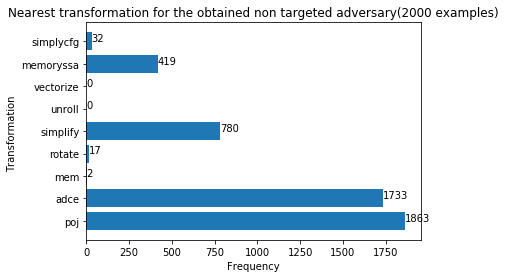

In [26]:
x = ["poj","adce","mem","rotate","simplify","unroll","vectorize","memoryssa","simplycfg"]
y = count3
plt.barh(x, y)
plt.ylabel("Transformation ")
plt.xlabel("Frequency")
plt.title("Nearest transformation for the obtained non targeted adversary(2000 examples)")

for index, value in enumerate(y):
    plt.text(value, index, str(value))

Dump generated adversarial examples for future use

In [17]:
# print(initial_adversaries1.shape)
# with open('pojadversary_untargeted2000.pkl', 'wb') as f:
#     pickle.dump(initial_adversaries1, f)

(2000, 300)


In [18]:
# initial_adversaries_y=[]
# for i in range(len(y_adv_1)):
#     y=y_adv_1[i].tolist()
#     initial_adversaries_y.append(y[0])
# initial_adversaries_y=np.array(initial_adversaries_y)
# print(initial_adversaries_y.shape)
# with open('pojadversary_untargeted_y2000.pkl', 'wb') as f:
#     pickle.dump(initial_adversaries_y, f)

(2000,)


In [19]:
# with open('pojadversary_untargeted_shuffle2000.pkl', 'wb') as f:
#     pickle.dump(shuffled_index, f)

In [27]:
# with open('pojadversary_untargeted2000.pkl', 'rb') as f:
#         initial_adversaries1=pickle.load(f)

In [28]:
# with open('pojadversary_untargeted_y2000.pkl', 'rb') as f:
#         initial_adversaries_y=pickle.load(f)

In [29]:
# with open('pojadversary_untargeted_shuffle2000.pkl', 'rb') as f:
#         ishuffled_index=pickle.load(f)